## 1 · Imports & Global Settings

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

import sys
import os
sys.path.append(os.path.abspath('../'))
 
from src.eda_utils import *

fraud_df = load_data("../data/raw/fraud_data.csv")
# ── Aesthetics ──
FRAUD_PAL = {0: "#4C72B0", 1: "#DD4444", "0": "#4C72B0", "1": "#DD4444"}   # blue = normal, red = fraud
SEED = 42
# set_aesthetics(palette_style="muted", font_scale=1.1)

Shape: (151112, 11)


## 2 · Load & Inspect Datasets

In [ ]:
dataset_overview(fraud_df)


Shape
(151112, 11)

Data Types
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

Missing Values
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Duplicates
0


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


## 3 · Data Quality Assessment

In [ ]:
fraud_df.shape

(151112, 11)

In [ ]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [ ]:
fraud_df.duplicated().sum()

np.int64(0)

In [ ]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

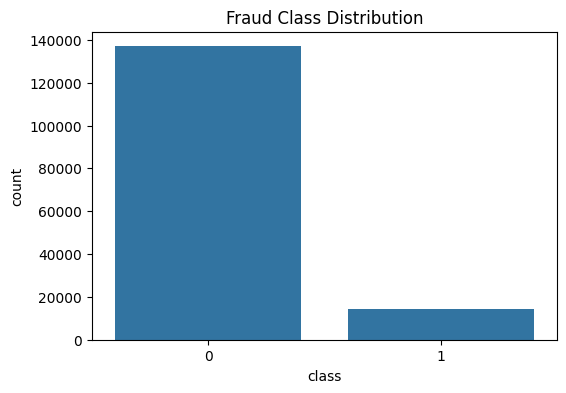

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=fraud_df, x="class")
plt.title("Fraud Class Distribution")
plt.show()

In [ ]:
fraud_df["class"].value_counts(normalize=True)*100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

<Axes: xlabel='purchase_value', ylabel='Count'>

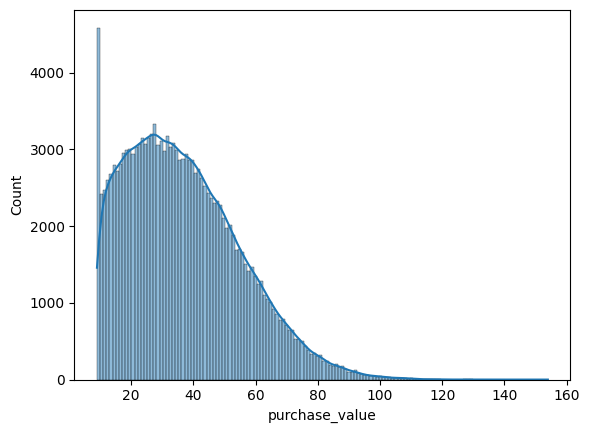

In [ ]:
sns.histplot(
    fraud_df["purchase_value"],
    kde=True
)

<Axes: xlabel='purchase_value'>

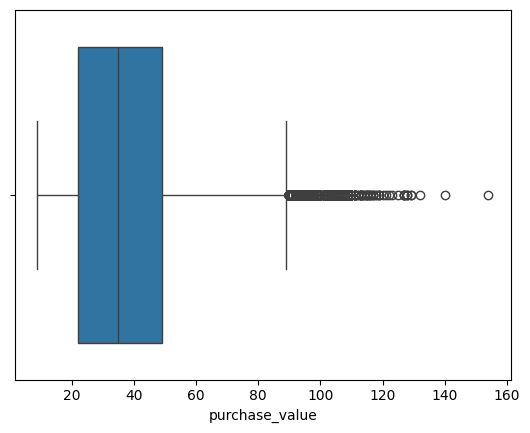

In [ ]:
sns.boxplot(
    x=fraud_df["purchase_value"]
)

## 4 · Class Distribution & Imbalance

<Axes: xlabel='age', ylabel='Count'>

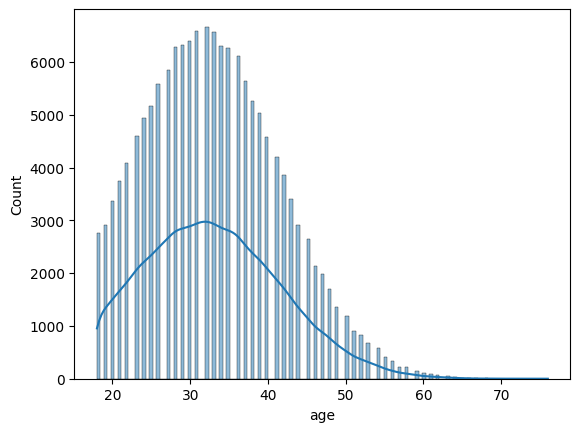

In [ ]:
sns.histplot(
    fraud_df["age"],
    kde=True
)

<Axes: xlabel='age'>

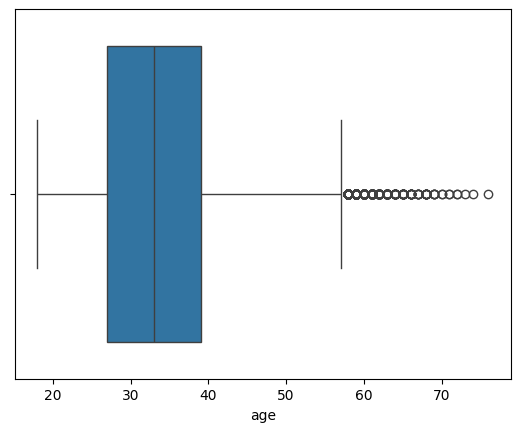

In [ ]:
sns.boxplot(
    x=fraud_df["age"]
)

<Axes: xlabel='count', ylabel='browser'>

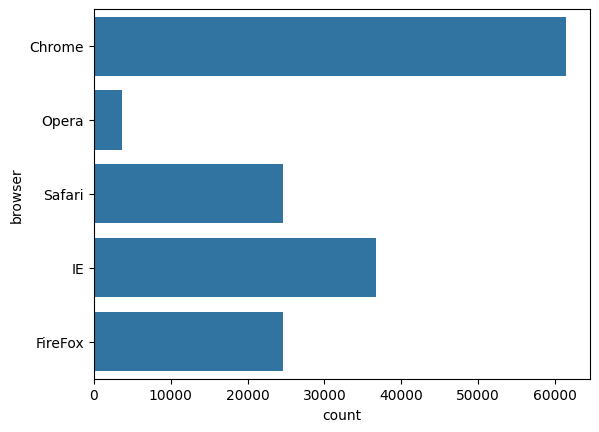

In [ ]:
sns.countplot(
    data=fraud_df,
    y="browser"
)

<Axes: xlabel='count', ylabel='source'>

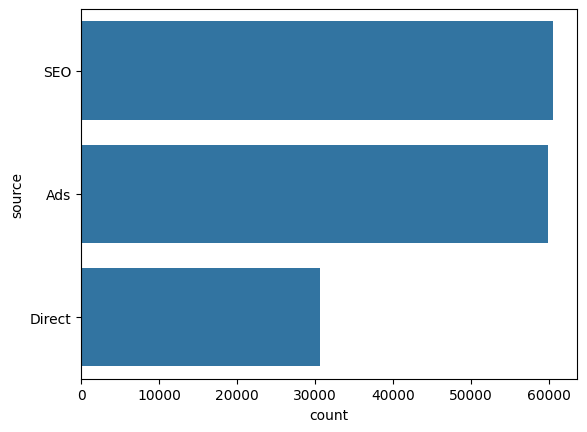

In [ ]:
sns.countplot(
    data=fraud_df,
    y="source"
)

<Axes: xlabel='sex', ylabel='count'>

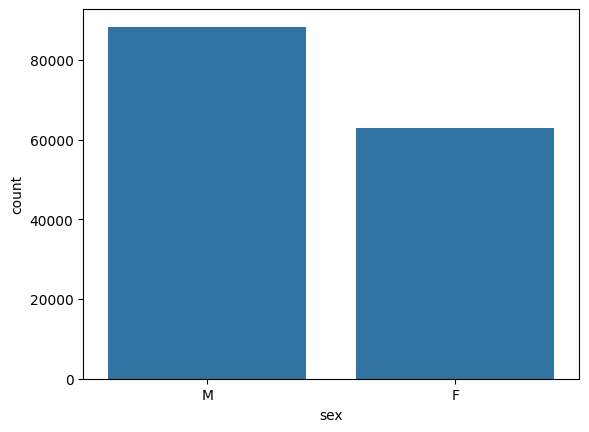

In [ ]:
sns.countplot(
    data=fraud_df,
    x="sex"
)

Purchase Value vs Fraud

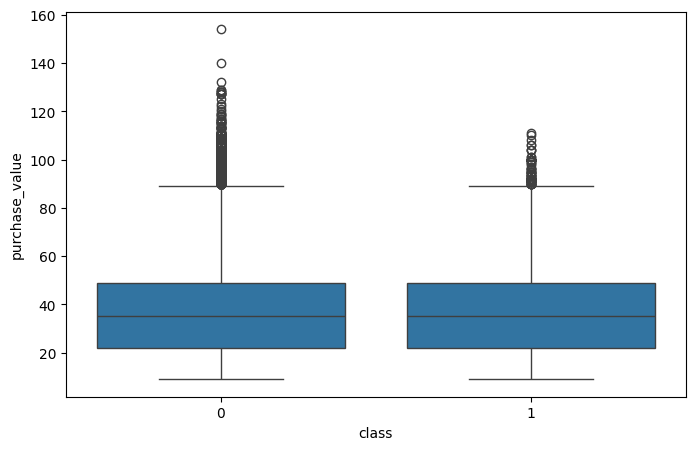

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=fraud_df,
    x="class",
    y="purchase_value"
)

plt.show()

<Axes: xlabel='class', ylabel='age'>

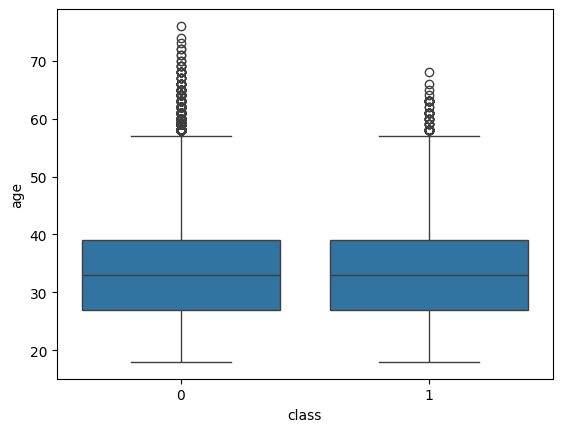

In [ ]:
sns.boxplot(
    data=fraud_df,
    x="class",
    y="age"
)

In [ ]:
browser_fraud = pd.crosstab(
    fraud_df["browser"],
    fraud_df["class"],
    normalize="index"
)

browser_fraud

class,0,1
browser,,
Chrome,0.901208,0.098792
FireFox,0.904835,0.095165
IE,0.913225,0.086775
Opera,0.910773,0.089227
Safari,0.909799,0.090201


<Axes: xlabel='browser'>

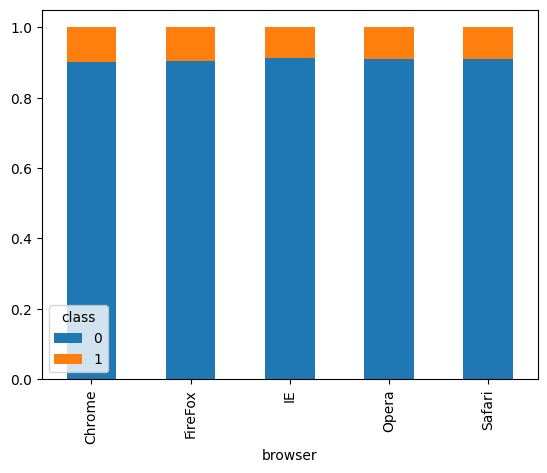

In [ ]:
browser_fraud.plot(
    kind="bar",
    stacked=True
)